<a href="https://colab.research.google.com/github/radia-ilhan/A03/blob/main/biooilimmcooling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

h_oil/h_air ratio = 2.333  (h_air=75.0 W/m2K, h_oil=175.0 W/m2K)
R_th_air = 0.1000 K/W
R_th_oil = 0.0429 K/W

Per-GPU thermal mass:
  A100 SXM (400 W): C_th = 150.0 J/K
  H100 SXM (700 W): C_th = 262.5 J/K
  H100 PCIe (350 W): C_th = 131.2 J/K

--- Steady-state die temperature (T_amb = 25 degC) ---
              GPU  TDP_W  C_th_J_per_K  T_ss_air_C  T_ss_oil_C  Delta_C (air - oil)
 A100 SXM (400 W)  400.0        150.00        65.0   42.142857            22.857143
 H100 SXM (700 W)  700.0        262.50        95.0   55.000000            40.000000
H100 PCIe (350 W)  350.0        131.25        60.0   40.000000            20.000000
A100 SXM (400 W): tau_air = 15.0 s, tau_oil = 6.4 s
H100 SXM (700 W): tau_air = 26.2 s, tau_oil = 11.2 s
H100 PCIe (350 W): tau_air = 13.1 s, tau_oil = 5.6 s


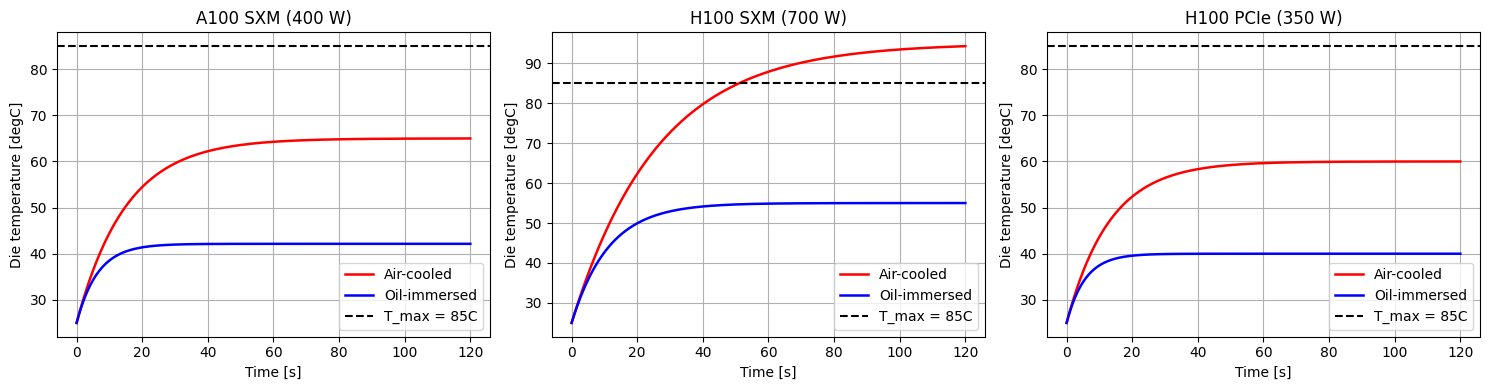

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
h_air = 75.0

# Single-phase dielectric oil immersion with light circulation, conservative
# end of the range reported for vegetable-oil-class fluids (Kanbur et al.,
# 2020, immersion-cooling heat transfer characterization)
h_oil = 175.0
ratio_h = h_oil / h_air
print(f"h_oil/h_air ratio = {ratio_h:.3f}  (h_air={h_air} W/m2K, h_oil={h_oil} W/m2K)")

# Baseline air-cooled junction-to-ambient resistance, representative of a
# server-class heatsink at rated airflow (consistent with NVIDIA H100
# thermal design guides)
R_th_air = 0.10
R_th_oil = R_th_air / ratio_h

print(f"R_th_air = {R_th_air:.4f} K/W")
print(f"R_th_oil = {R_th_oil:.4f} K/W")

# TDP source: NVIDIA official datasheets (A100 SXM4 400W, H100 SXM5 700W,
# H100 PCIe 350W)
gpu_names = ['A100 SXM (400 W)', 'H100 SXM (700 W)', 'H100 PCIe (350 W)']
gpu_tdp = np.array([400.0, 700.0, 350.0])  # W

# Thermal mass (die + heatsink/cold-plate assembly), scaled from TDP class
# since higher-power parts use physically larger heatsink assemblies.
# Reference: 150 J/K at 400W, consistent order-of-magnitude with a
# copper cold-plate + baseplate mass of ~0.3-0.5 kg (c_copper ~385 J/kg.K)
C_th_ref = 150.0
gpu_Cth = C_th_ref * (gpu_tdp / 400.0)

print("\nPer-GPU thermal mass:")
for name, c in zip(gpu_names, gpu_Cth):
    print(f"  {name}: C_th = {c:.1f} J/K")

T_amb = 25.0
print(f"\n--- Steady-state die temperature (T_amb = {T_amb:.0f} degC) ---")
T_ss_air = T_amb + gpu_tdp * R_th_air
T_ss_oil = T_amb + gpu_tdp * R_th_oil

results = pd.DataFrame({
    'GPU': gpu_names,
    'TDP_W': gpu_tdp,
    'C_th_J_per_K': gpu_Cth,
    'T_ss_air_C': T_ss_air,
    'T_ss_oil_C': T_ss_oil,
    'Delta_C (air - oil)': T_ss_air - T_ss_oil
})
print(results.to_string(index=False))

t = np.arange(0, 120.1, 0.1)
fig, axes = plt.subplots(1, len(gpu_tdp), figsize=(15, 4))

for i, (Q, Cth) in enumerate(zip(gpu_tdp, gpu_Cth)):
    tau_air = R_th_air * Cth
    tau_oil = R_th_oil * Cth
    T_air = T_amb + Q * R_th_air * (1 - np.exp(-t / tau_air))
    T_oil = T_amb + Q * R_th_oil * (1 - np.exp(-t / tau_oil))

    ax = axes[i]
    ax.plot(t, T_air, 'r-', linewidth=1.8, label='Air-cooled')
    ax.plot(t, T_oil, 'b-', linewidth=1.8, label='Oil-immersed')
    ax.axhline(85.0, color='k', linestyle='--', label='T_max = 85C')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Die temperature [degC]')
    ax.set_title(gpu_names[i])
    ax.legend(loc='lower right')
    ax.grid(True)
    print(f"{gpu_names[i]}: tau_air = {tau_air:.1f} s, tau_oil = {tau_oil:.1f} s")

plt.tight_layout()
plt.show()


Final die temperature: 45.00 degC (setpoint 45.0 degC)
Peak die temperature during transient: 50.33 degC
Max pump duty cycle reached: 0.67

Steady-state tracking error: 0.002 degC
Overshoot: 11.85% (50.33 degC peak vs 45.0 degC setpoint)
Settling time (within 2% band) after load step: 8.7 s

Deployment comparison vs Ma et al. (2025), Advanced Engineering Informatics:
Metric                        Ma et al. Transformer-GRU         This work (STM32 PID)             
--------------------------------------------------------------------------------------------------
Problem solved                Coolant temp. forecasting         Setpoint regulation (control)     
Reported performance          R2=81.07%, MSE=1.349              SS error=0.00C, overshoot=11.9%   
Training data required        8,760 hrs/yr, 6-ch telemetry      None (fixed-gain PID)             
Inference-time compute        GPU-trained deep model            kB-scale loop on MCU              
Facility integration          SCADA 

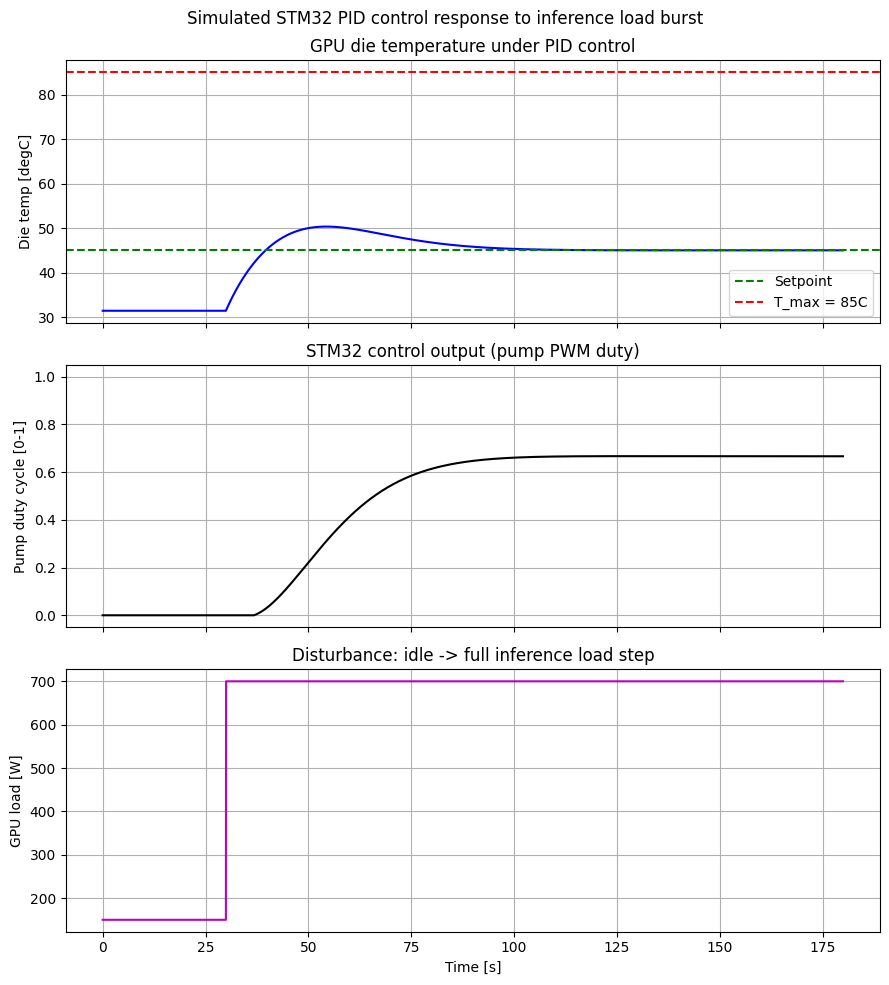

In [2]:
import numpy as np
import matplotlib.pyplot as plt

h_air = 75.0
h_oil = 175.0
ratio_h = h_oil / h_air

T_amb = 25.0
T_max = 85.0  # max safe junction temp, NVIDIA H100 datasheet
R_air = 0.10
R_max = R_air / ratio_h   # oil resistance at minimum pump flow
R_min = 0.5 * R_max       # oil resistance at maximum pump flow
                           # (assumption: doubling flow roughly halves R_th,
C_th = 262.5  # H100 SXM thermal mass, TDP-scaled from 400W/150 J/K reference
T_set = 45.0
Q_idle = 150.0
Q_full = 700.0  # H100 SXM TDP, NVIDIA datasheet
t_step = 30.0
dt = 0.05
t_end = 180.0
N = int(round(t_end / dt))
t = np.arange(N) * dt

Kp, Ki, Kd = 0.02, 0.004, 0.05

T = np.zeros(N)
u = np.zeros(N)
e = np.zeros(N)
I_term = 0.0
T[0] = T_amb + Q_idle * R_max
for k in range(1, N):
    Q = Q_idle if t[k] < t_step else Q_full
    e[k] = T[k-1] - T_set
    de = (e[k] - e[k-1]) / dt
    I_tentative = I_term + e[k] * dt
    u_tentative = Kp * e[k] + Ki * I_tentative + Kd * de
    if u_tentative > 1:
        u[k] = 1.0
    elif u_tentative < 0:
        u[k] = 0.0
    else:
        u[k] = u_tentative
        I_term = I_tentative
    R_th_now = R_min + (R_max - R_min) * (1 - u[k])
    dTdt = (Q - (T[k-1] - T_amb) / R_th_now) / C_th
    T[k] = T[k-1] + dTdt * dt
print(f"Final die temperature: {T[-1]:.2f} degC (setpoint {T_set:.1f} degC)")
print(f"Peak die temperature during transient: {T.max():.2f} degC")
print(f"Max pump duty cycle reached: {u.max():.2f}")

ss_window = T[int(150/dt):]
ss_error_abs = np.abs(ss_window - T_set).mean()
overshoot_pct = ((T.max() - T_set) / T_set) * 100
settling_mask = np.abs(T - T_set) <= 0.02 * T_set
settling_idx = np.argmax(settling_mask[int(t_step/dt):]) + int(t_step/dt)
settling_time = t[settling_idx] - t_step
print(f"\nSteady-state tracking error: {ss_error_abs:.3f} degC")
print(f"Overshoot: {overshoot_pct:.2f}% ({T.max():.2f} degC peak vs {T_set:.1f} degC setpoint)")
print(f"Settling time (within 2% band) after load step: {settling_time:.1f} s")
print("\nDeployment comparison vs Ma et al. (2025), Advanced Engineering Informatics:")
rows = [
    ("Problem solved", "Coolant temp. forecasting", "Setpoint regulation (control)"),
    ("Reported performance", "R2=81.07%, MSE=1.349", f"SS error={ss_error_abs:.2f}C, overshoot={overshoot_pct:.1f}%"),
    ("Training data required", "8,760 hrs/yr, 6-ch telemetry", "None (fixed-gain PID)"),
    ("Inference-time compute", "GPU-trained deep model", "kB-scale loop on MCU"),
    ("Facility integration", "SCADA (Johnson Controls Metasys)", "Standalone sensor + MCU"),
    ("Approx. added hardware cost", "GPU training budget + SCADA link", "< $50 (STM32+DS18B20+driver)"),
    ("Coolant medium addressed", "Optimizes existing water/glycol", "Replaces medium (bio-oil)"),
]
col1, col2, col3 = 30, 34, 34
print(f"{'Metric':<{col1}}{'Ma et al. Transformer-GRU':<{col2}}{'This work (STM32 PID)':<{col3}}")
print("-" * (col1 + col2 + col3))
for a, b, c in rows:
    print(f"{a:<{col1}}{b:<{col2}}{c:<{col3}}")

fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
axes[0].plot(t, T, 'b-', linewidth=1.5)
axes[0].axhline(T_set, color='g', linestyle='--', label='Setpoint')
axes[0].axhline(T_max, color='r', linestyle='--', label='T_max = 85C')
axes[0].set_ylabel('Die temp [degC]')
axes[0].set_title('GPU die temperature under PID control')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(t, u, 'k-', linewidth=1.5)
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_ylabel('Pump duty cycle [0-1]')
axes[1].set_title('STM32 control output (pump PWM duty)')
axes[1].grid(True)
Q_profile = np.where(t < t_step, Q_idle, Q_full)
axes[2].plot(t, Q_profile, 'm-', linewidth=1.5)
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('GPU load [W]')
axes[2].set_title('Disturbance: idle -> full inference load step')
axes[2].grid(True)
fig.suptitle('Simulated STM32 PID control response to inference load burst')
plt.tight_layout()
plt.show()


      Coolant  k_W_mK  Cost_USD_L  RelViscosity_est  ThermalSuitability  CostScore  WaterIndependence  Sustainability  FeasibilityScore
   Canola oil   0.170         2.0               3.0            0.141667   0.986486                1.0            0.95          0.744538
Sunflower oil   0.170         2.0               3.0            0.141667   0.986486                1.0            0.95          0.744538
  Mineral oil   0.130         5.5               1.0            0.478704   0.939189                1.0            0.30          0.704473
        Novec   0.065        75.0               0.5            0.517130   0.000000                1.0            0.10          0.449282
 Water/glycol   0.600         1.0               0.3            1.000000   1.000000                0.0            0.60          0.605000


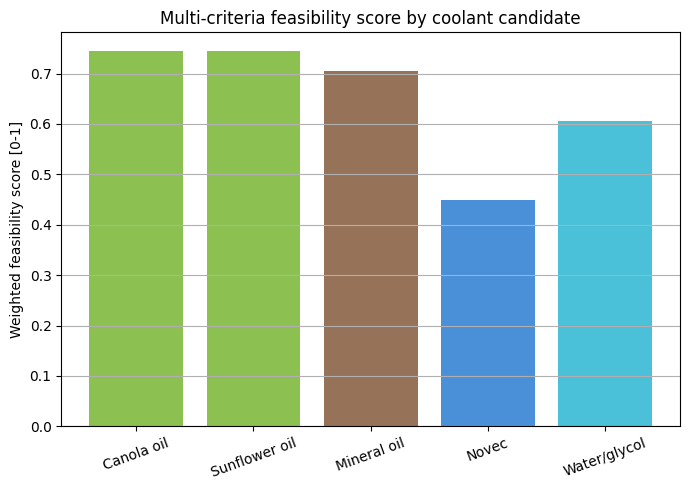

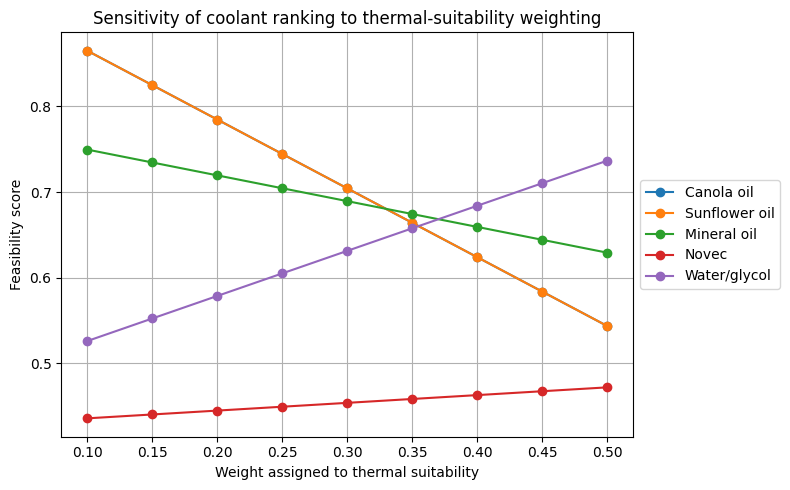


Top-ranked coolant across weight sweep: {'Mineral oil', 'Water/glycol', 'Canola oil'}
Ranking stable across sweep: False


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
coolants = ['Canola oil', 'Sunflower oil', 'Mineral oil', 'Novec', 'Water/glycol']
n = len(coolants)
# Thermal conductivity [W/m.K]: canola/sunflower ~0.17 (natural ester
# dielectric fluid literature, e.g. Rafiq et al. 2020), mineral oil ~0.13
# (standard dielectric mineral oil datasheets), Novec 7100 ~0.065 (3M
# datasheet), water/glycol 50/50 ~0.60 (ASHRAE Fundamentals)
k_thermal = np.array([0.17, 0.17, 0.13, 0.065, 0.60])
# Cost [USD/L]: market-range estimates
cost_usd_L = np.array([2.0, 2.0, 5.5, 75.0, 1.0])
# Relative viscosity vs mineral oil, approximated from published viscosity
viscosity_rel = np.array([3.0, 3.0, 1.0, 0.5, 0.3])
biodegradable = np.array([1, 1, 0, 0, 0.5])  # manufacturer SDS / literature
# Accessibility and infrastructure complexity: analyst-assigned 0-1 scores
accessibility = np.array([0.9, 0.9, 0.6, 0.2, 0.7])
infra_complexity = np.array([0.2, 0.2, 0.3, 0.3, 0.9])

# Water independence: closed-loop bio-oil/Novec systems need no evaporative
# tower or adjacent water body; water/glycol systems (as in Zhou et al.)
# depend on evaporative cooling and/or a natural water source
water_independence = np.array([1.0, 1.0, 1.0, 1.0, 0.0])
norm_k = k_thermal / k_thermal.max()
norm_cost = 1 - (cost_usd_L - cost_usd_L.min()) / (cost_usd_L.max() - cost_usd_L.min())
norm_visc = 1 - (viscosity_rel - viscosity_rel.min()) / (viscosity_rel.max() - viscosity_rel.min())
norm_bio = biodegradable
norm_acc = accessibility
norm_infra = 1 - infra_complexity
thermal_suitability = 0.5 * norm_k + 0.5 * norm_visc
sustainability = 0.5 * norm_bio + 0.5 * norm_acc

# Weights: thermal and cost are the primary comparison axes against
# engineered dielectrics, water independence is the central novelty claim
# of this work, accessibility/sustainability are secondary
w_thermal = 0.25
w_cost = 0.25
w_water = 0.20
w_access = 0.15
w_sustain = 0.15
score = (w_thermal * thermal_suitability + w_cost * norm_cost
         + w_water * water_independence + w_access * norm_infra
         + w_sustain * sustainability)
results = pd.DataFrame({
    'Coolant': coolants,
    'k_W_mK': k_thermal,
    'Cost_USD_L': cost_usd_L,
    'RelViscosity_est': viscosity_rel,
    'ThermalSuitability': thermal_suitability,
    'CostScore': norm_cost,
    'WaterIndependence': water_independence,
    'Sustainability': sustainability,
    'FeasibilityScore': score
})
print(results.to_string(index=False))
plt.figure(figsize=(7, 5))
plt.bar(coolants, score, color=['#8CC152', '#8CC152', '#967259', '#4A90D9', '#4AC0D9'])
plt.xticks(rotation=20)
plt.ylabel('Weighted feasibility score [0-1]')
plt.title('Multi-criteria feasibility score by coolant candidate')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()
w_thermal_range = np.arange(0.1, 0.51, 0.05)
score_matrix = np.zeros((len(w_thermal_range), n))
for i, wt in enumerate(w_thermal_range):
    remaining = 1 - wt
    wc = remaining * (0.25 / 0.75)
    ww = remaining * (0.20 / 0.75)
    wa = remaining * (0.15 / 0.75)
    ws = remaining * (0.15 / 0.75)
    score_matrix[i, :] = (wt * thermal_suitability + wc * norm_cost
                           + ww * water_independence + wa * norm_infra
                           + ws * sustainability)
plt.figure(figsize=(8, 5))
for j in range(n):
    plt.plot(w_thermal_range, score_matrix[:, j], '-o', linewidth=1.5, label=coolants[j])
plt.xlabel('Weight assigned to thermal suitability')
plt.ylabel('Feasibility score')
plt.title('Sensitivity of coolant ranking to thermal-suitability weighting')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()
rankings = np.argmax(score_matrix, axis=1)
top_coolants = [coolants[i] for i in rankings]
print(f"\nTop-ranked coolant across weight sweep: {set(top_coolants)}")
print(f"Ranking stable across sweep: {len(set(top_coolants)) == 1}")
